In [6]:
import sys

import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)

3.13.9 2.1.3 2.3.3 1.6.1


In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 3246

data = pd.read_csv("data/heart_disease.csv")
feature_names = [c for c in data.columns if c != "disease"]
X, y = data[feature_names].to_numpy(), data["disease"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)

(297, 14) 0.461 (207, 13) (90, 13)


# Task 2: Decision Trees

Student: SHAKENBAYEV (S24073246)

**SEED = 3246** (last 4 digits of the student ID)

## Part 1 

In [18]:
toy = pd.DataFrame({
    "age_55_plus": [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
    "exercise_angina": [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "male": [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    "high_bp": [1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
    "disease": [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
})
toy.index = [f"p{i}" for i in range(1, 13)]
print(toy)
print(toy["disease"].value_counts())

     age_55_plus  exercise_angina  male  high_bp  disease
p1             1                1     1        1        1
p2             1                1     1        1        1
p3             1                1     1        0        1
p4             1                1     0        1        1
p5             1                0     0        1        1
p6             0                0     0        0        1
p7             1                0     1        0        0
p8             0                0     1        0        0
p9             0                0     1        0        0
p10            0                0     0        1        0
p11            0                0     0        1        0
p12            0                0     0        0        0
disease
1    6
0    6
Name: count, dtype: int64


### Parent entropy

$$H = -\sum_c p_c \log_2 p_c$$

In the parent node there are 12 patients: 6 with disease ($p_1 = 6/12 = 0.5$) and 6 without ($p_0 = 6/12 = 0.5$).

$$H(\text{parent}) = -\left(\frac{6}{12}\log_2\frac{6}{12} + \frac{6}{12}\log_2\frac{6}{12}\right) = -\left(0.5 \cdot (-1) + 0.5 \cdot (-1)\right) = 1 \text{ bit}$$

The classes are split evenly, so the entropy is at its maximum for two classes.

In [19]:
p = toy["disease"].value_counts(normalize=True)
H_parent = -(p * np.log2(p)).sum()
print(H_parent)

1.0


### Root: information gain of each feature

Gain = H(parent) − weighted average of H(children).

#### age_55_plus

| branch | patients | disease = 1 | disease = 0 |
|---|---|---|---|
| age_55_plus = 1 (p1–p5, p7) | 6 | 5 | 1 |
| age_55_plus = 0 (p6, p8–p12) | 6 | 1 | 5 |

Both children have proportions 5/6 and 1/6:

$$H(\text{child}) = -\left(\frac{5}{6}\log_2\frac{5}{6} + \frac{1}{6}\log_2\frac{1}{6}\right) = -\left(0.8333 \cdot (-0.2630) + 0.1667 \cdot (-2.5850)\right) = 0.2192 + 0.4308 = 0.6500$$

$$H(\text{children}) = \frac{6}{12} \cdot 0.6500 + \frac{6}{12} \cdot 0.6500 = 0.6500$$

$$IG(\text{age\_55\_plus}) = 1 - 0.6500 = 0.3500$$

In [20]:
def H_toy(y):
    p = np.bincount(y) / len(y)
    p = p[p > 0]
    return -(p * np.log2(p)).sum()

def gain_toy(df, feature):
    left = df[feature] == 1
    y_all = df["disease"].to_numpy()
    w_left = left.mean()
    h_children = w_left * H_toy(y_all[left]) + (1 - w_left) * H_toy(y_all[~left])
    return H_toy(y_all) - h_children

print(gain_toy(toy, "age_55_plus"))

0.3499775783516459


#### exercise_angina

| branch | patients | disease = 1 | disease = 0 |
|---|---|---|---|
| exercise_angina = 1 (p1–p4) | 4 | 4 | 0 |
| exercise_angina = 0 (p5–p12) | 8 | 2 | 6 |

The left branch is pure, so $H = 0$ (with $0 \cdot \log_2 0 = 0$). The right branch has proportions 2/8 = 0.25 and 6/8 = 0.75:

$$H(\text{right}) = -\left(\frac{2}{8}\log_2\frac{2}{8} + \frac{6}{8}\log_2\frac{6}{8}\right) = -\left(0.25 \cdot (-2) + 0.75 \cdot (-0.4150)\right) = 0.5 + 0.3113 = 0.8113$$

$$H(\text{children}) = \frac{4}{12} \cdot 0 + \frac{8}{12} \cdot 0.8113 = 0.5409$$

$$IG(\text{exercise\_angina}) = 1 - 0.5409 = 0.4591$$

In [21]:
print(gain_toy(toy, "exercise_angina"))

0.45914791702724467


#### male

| branch | patients | disease = 1 | disease = 0 |
|---|---|---|---|
| male = 1 (p1–p3, p7–p9) | 6 | 3 | 3 |
| male = 0 (p4–p6, p10–p12) | 6 | 3 | 3 |

Both children have the same class mix as the parent (3/6 and 3/6), so each has $H = 1$:

$$H(\text{children}) = \frac{6}{12} \cdot 1 + \frac{6}{12} \cdot 1 = 1$$

$$IG(\text{male}) = 1 - 1 = 0$$

The split tells us nothing about the disease at the root.

In [22]:
print(gain_toy(toy, "male"))

0.0


#### high_bp

| branch | patients | disease = 1 | disease = 0 |
|---|---|---|---|
| high_bp = 1 (p1, p2, p4, p5, p10, p11) | 6 | 4 | 2 |
| high_bp = 0 (p3, p6, p7, p8, p9, p12) | 6 | 2 | 4 |

Both children have proportions 4/6 and 2/6 (in one the majority is disease, in the other no disease), so they have the same entropy:

$$H(\text{child}) = -\left(\frac{4}{6}\log_2\frac{4}{6} + \frac{2}{6}\log_2\frac{2}{6}\right) = -\left(0.6667 \cdot (-0.5850) + 0.3333 \cdot (-1.5850)\right) = 0.3900 + 0.5283 = 0.9183$$

$$H(\text{children}) = \frac{6}{12} \cdot 0.9183 + \frac{6}{12} \cdot 0.9183 = 0.9183$$

$$IG(\text{high\_bp}) = 1 - 0.9183 = 0.0817$$

In [23]:
print(gain_toy(toy, "high_bp"))

0.08170416594551044


### Root: summary

| feature | information gain |
|---|---|
| age_55_plus | 0.3500 |
| exercise_angina | 0.4591 |
| male | 0.0000 |
| high_bp | 0.0817 |

The largest gain belongs to **exercise_angina** (0.4591), so the tree puts it at the root.

In [24]:
features = ["age_55_plus", "exercise_angina", "male", "high_bp"]
gains = {f: round(gain_toy(toy, f), 4) for f in features}
print(gains)
print("root:", max(gains, key=gains.get))

{'age_55_plus': np.float64(0.35), 'exercise_angina': np.float64(0.4591), 'male': np.float64(0.0), 'high_bp': np.float64(0.0817)}
root: exercise_angina


### One level down

After splitting on exercise_angina:
- exercise_angina = 1 (p1–p4): 4 patients, all with disease. The branch is pure, so it becomes a leaf.
- exercise_angina = 0 (p5–p12): 8 patients, 2 with disease and 6 without. This branch is still impure, so we split it further.

Entropy of the impure branch (proportions 2/8 and 6/8):

$$H(\text{branch}) = -\left(\frac{2}{8}\log_2\frac{2}{8} + \frac{6}{8}\log_2\frac{6}{8}\right) = 0.5 + 0.3113 = 0.8113$$

Now we compute the gains of the three remaining features (age_55_plus, male, high_bp) inside this branch only.

In [25]:
branch = toy[toy["exercise_angina"] == 0]
print(branch)
print(H_toy(branch["disease"].to_numpy())) 


     age_55_plus  exercise_angina  male  high_bp  disease
p5             1                0     0        1        1
p6             0                0     0        0        1
p7             1                0     1        0        0
p8             0                0     1        0        0
p9             0                0     1        0        0
p10            0                0     0        1        0
p11            0                0     0        1        0
p12            0                0     0        0        0
0.8112781244591328


#### Inside the branch: age_55_plus

| branch | patients | disease = 1 | disease = 0 |
|---|---|---|---|
| age_55_plus = 1 (p5, p7) | 2 | 1 | 1 |
| age_55_plus = 0 (p6, p8–p12) | 6 | 1 | 5 |

$$H(\text{left}) = -\left(\frac{1}{2}\log_2\frac{1}{2} + \frac{1}{2}\log_2\frac{1}{2}\right) = 1$$

$$H(\text{right}) = -\left(\frac{1}{6}\log_2\frac{1}{6} + \frac{5}{6}\log_2\frac{5}{6}\right) = 0.4308 + 0.2192 = 0.6500$$

$$H(\text{children}) = \frac{2}{8} \cdot 1 + \frac{6}{8} \cdot 0.6500 = 0.25 + 0.4875 = 0.7375$$

$$IG(\text{age\_55\_plus} \mid \text{branch}) = 0.8113 - 0.7375 = 0.0738$$

In [26]:
print(gain_toy(branch, "age_55_plus"))

0.0737613082228673


#### Inside the branch: male

| branch | patients | disease = 1 | disease = 0 |
|---|---|---|---|
| male = 1 (p7, p8, p9) | 3 | 0 | 3 |
| male = 0 (p5, p6, p10, p11, p12) | 5 | 2 | 3 |

The left branch is pure, so $H = 0$. The right branch has proportions 2/5 = 0.4 and 3/5 = 0.6:

$$H(\text{right}) = -\left(0.4\log_2 0.4 + 0.6\log_2 0.6\right) = 0.5288 + 0.4422 = 0.9710$$

$$H(\text{children}) = \frac{3}{8} \cdot 0 + \frac{5}{8} \cdot 0.9710 = 0.6069$$

$$IG(\text{male} \mid \text{branch}) = 0.8113 - 0.6069 = 0.2044$$

In [27]:
print(gain_toy(branch, "male"))

0.20443400292496494


#### Inside the branch: high_bp

| branch | patients | disease = 1 | disease = 0 |
|---|---|---|---|
| high_bp = 1 (p5, p10, p11) | 3 | 1 | 2 |
| high_bp = 0 (p6, p7, p8, p9, p12) | 5 | 1 | 4 |

$$H(\text{left}) = -\left(\frac{1}{3}\log_2\frac{1}{3} + \frac{2}{3}\log_2\frac{2}{3}\right) = 0.5283 + 0.3900 = 0.9183$$

$$H(\text{right}) = -\left(0.2\log_2 0.2 + 0.8\log_2 0.8\right) = 0.4644 + 0.2575 = 0.7219$$

$$H(\text{children}) = \frac{3}{8} \cdot 0.9183 + \frac{5}{8} \cdot 0.7219 = 0.3444 + 0.4512 = 0.7956$$

$$IG(\text{high\_bp} \mid \text{branch}) = 0.8113 - 0.7956 = 0.0157$$

In [28]:
print(gain_toy(branch, "high_bp"))

0.015712127384097774


#### Inside the branch: summary

| feature | gain at the root | gain inside exercise_angina = 0 |
|---|---|---|
| age_55_plus | 0.3500 | 0.0738 |
| male | 0.0000 | 0.2044 |
| high_bp | 0.0817 | 0.0157 |

Inside the impure branch the largest gain belongs to **male** (0.2044), so the tree splits this branch on male. At the root the same feature had a gain of 0.

**Why a useless feature can win below.** At the root, male has a gain of 0 because its two effects cancel out: among the exercise_angina = 1 patients (all diseased) most are male, but among the exercise_angina = 0 patients all males are healthy. After the root split removes the first group, only the second effect remains, so male becomes the most informative feature.

In [29]:
branch_features = ["age_55_plus", "male", "high_bp"]
branch_gains = {f: round(float(gain_toy(branch, f)), 4) for f in branch_features}
print(branch_gains)
print("chosen in the branch:", max(branch_gains, key=branch_gains.get))

{'age_55_plus': 0.0738, 'male': 0.2044, 'high_bp': 0.0157}
chosen in the branch: male


## Part 2

In [30]:
def entropy(y):
    """Entropy in bits of an array of integer class labels."""
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0
    p = np.bincount(y) / len(y)
    p = p[p > 0]                       # 0 * log2(0) is treated as 0
    return float((p * np.log2(1 / p)).sum())


def information_gain(y, left):
    """Entropy of y minus the size-weighted entropy of y[left] and y[~left]; left is a boolean mask."""
    y = np.asarray(y)
    left = np.asarray(left, dtype=bool)
    n = len(y)
    n_left = left.sum()
    n_right = n - n_left
    children = (n_left / n) * entropy(y[left]) + (n_right / n) * entropy(y[~left])
    return entropy(y) - children

In [31]:
y_toy = toy["disease"].to_numpy()
print("entropy:", entropy(y_toy))
for f in ["age_55_plus", "exercise_angina", "male", "high_bp"]:
    print(f, round(information_gain(y_toy, (toy[f] == 1).to_numpy()), 4))

entropy: 1.0
age_55_plus 0.35
exercise_angina 0.4591
male 0.0
high_bp 0.0817


In [33]:
def best_split(X, y, min_samples_leaf=1):
    """Return (feature_index, threshold, gain) of the best split, or None if no valid split exists."""
    X = np.asarray(X)
    y = np.asarray(y)
    best = None
    best_gain = -np.inf
    for j in range(X.shape[1]):                      
        values = np.unique(X[:, j])                  
        thresholds = (values[:-1] + values[1:]) / 2 
        for thr in thresholds:                      
            left = X[:, j] <= thr
            n_left = left.sum()
            n_right = len(y) - n_left
            if n_left < min_samples_leaf or n_right < min_samples_leaf:
                continue                            
            gain = information_gain(y, left)
            if gain > best_gain + 1e-12:
                best_gain = gain
                best = (j, float(thr), float(gain))
    return best

In [34]:
X_toy = toy.drop(columns="disease").to_numpy()
print(best_split(X_toy, y_toy))
print(best_split(X_toy, y_toy, min_samples_leaf=5))

(1, 0.5, 0.4591479170272448)
(0, 0.5, 0.3499775783516459)


In [35]:
from sklearn.tree import DecisionTreeClassifier

ref = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=SEED).fit(X_train, y_train)
print("sklearn:", feature_names[ref.tree_.feature[0]], ref.tree_.threshold[0])

mine = best_split(X_train, y_train)
print("mine:   ", feature_names[mine[0]], mine[1], "gain =", mine[2])

sklearn: cp 3.5
mine:    cp 3.5 gain = 0.207530624597698


In [37]:
def _leaf(y):
    """Make a leaf that predicts the majority class (a tie goes to the smaller label)."""
    return {"leaf": True, "label": int(np.bincount(y).argmax()), "n": int(len(y))}


def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Grow a tree recursively and return it as nested dicts (or any structure you like)."""
    X = np.asarray(X)
    y = np.asarray(y)
    # leaf rules: pure node, depth limit reached, or no valid split
    if len(np.unique(y)) == 1 or (max_depth is not None and depth == max_depth):
        return _leaf(y)
    split = best_split(X, y, min_samples_leaf)
    if split is None:
        return _leaf(y)
    j, thr, gain = split
    left = X[:, j] <= thr
    return {
        "leaf": False,
        "feature": j,
        "threshold": thr,
        "left": build_tree(X[left], y[left], max_depth, min_samples_leaf, depth + 1),
        "right": build_tree(X[~left], y[~left], max_depth, min_samples_leaf, depth + 1),
    }


def predict_tree(tree, X):
    """Return one predicted label per row of X."""
    X = np.asarray(X)

    def predict_row(node, x):
        while not node["leaf"]:
            node = node["left"] if x[node["feature"]] <= node["threshold"] else node["right"]
        return node["label"]

    return np.array([predict_row(tree, x) for x in X])

In [38]:
tree_toy = build_tree(X_toy, y_toy)
pred_toy = predict_tree(tree_toy, X_toy)
print(pred_toy)
print(y_toy)
print((pred_toy == y_toy).mean())

[1 1 1 1 1 0 0 0 0 0 0 0]
[1 1 1 1 1 1 0 0 0 0 0 0]
0.9166666666666666


In [39]:
depths = [1, 2, 3, 4, 5, None]
rows = []
for d in depths:
    my_tree = build_tree(X_train, y_train, max_depth=d)
    sk_tree = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED).fit(X_train, y_train)
    pred_mine = predict_tree(my_tree, X_test)
    pred_sk = sk_tree.predict(X_test)
    rows.append({
        "max_depth": "unlimited" if d is None else d,
        "agreement on test": (pred_mine == pred_sk).mean(),
    })
agreement_table = pd.DataFrame(rows)
print(agreement_table.to_string(index=False))

max_depth  agreement on test
        1           1.000000
        2           1.000000
        3           1.000000
        4           1.000000
        5           1.000000
unlimited           0.966667


In [40]:
my_full = build_tree(X_train, y_train)
sk_full = DecisionTreeClassifier(criterion="entropy", random_state=SEED).fit(X_train, y_train)

def count_leaves(node):
    return 1 if node["leaf"] else count_leaves(node["left"]) + count_leaves(node["right"])

print("leaves: mine", count_leaves(my_full), "| sklearn", sk_full.get_n_leaves())
print("train accuracy: mine", (predict_tree(my_full, X_train) == y_train).mean(),
      "| sklearn", sk_full.score(X_train, y_train))

diff = np.where(predict_tree(my_full, X_test) != sk_full.predict(X_test))[0]
print("test rows where they disagree:", diff)

leaves: mine 36 | sklearn 37
train accuracy: mine 1.0 | sklearn 1.0
test rows where they disagree: [14 23 28]


In [42]:
t = sk_full.tree_

def first_diff(node, i, Xs, ys, path="root"):
    """Walk both trees together; return the first node where they split differently."""
    mine_leaf = node["leaf"]
    sk_leaf = t.children_left[i] == -1
    if mine_leaf and sk_leaf:
        return None
    if mine_leaf != sk_leaf or node["feature"] != t.feature[i] or not np.isclose(node["threshold"], t.threshold[i]):
        return path, node, i, Xs, ys
    left = Xs[:, node["feature"]] <= node["threshold"]
    r = first_diff(node["left"], t.children_left[i], Xs[left], ys[left], path + "/L")
    if r is not None:
        return r
    return first_diff(node["right"], t.children_right[i], Xs[~left], ys[~left], path + "/R")

res = first_diff(my_full, 0, X_train, y_train)
path, node, i, Xs, ys = res
print("first difference at:", path, "| rows in this node:", len(ys), "| class counts:", np.bincount(ys))

if node["leaf"] or t.children_left[i] == -1:
    print("one tree stops here and the other keeps splitting")
else:
    f_sk, thr_sk = t.feature[i], t.threshold[i]
    g_mine = information_gain(ys, Xs[:, node["feature"]] <= node["threshold"])
    g_sk = information_gain(ys, Xs[:, f_sk] <= thr_sk)
    print("mine:   ", feature_names[node["feature"]], node["threshold"], "gain =", g_mine)
    print("sklearn:", feature_names[f_sk], thr_sk, "gain =", g_sk)

first difference at: root/L/L/R | rows in this node: 4 | class counts: [3 1]
mine:    chol 235.0 gain = 0.8112781244591328
sklearn: thalach 174.5 gain = 0.8112781244591328


### Part 2: comparison with scikit-learn 

**1. Do `entropy` and `information_gain` reproduce the hand values of Part 1?** Yes. The entropy of the parent is 1.0, and the gains of age_55_plus, exercise_angina, male and high_bp are 0.35, 0.4591, 0.0 and 0.0817, the same as in the hand calculation.

**2. Does `best_split` choose the same split as scikit-learn at the root?** Yes. Both choose `cp` with the threshold 3.5 (my gain is 0.2075).

**3. Agreement of my tree and scikit-learn's tree on the test split (90 rows):**

| max_depth | agreement on test |
|---|---|
| 1 | 1.0000 |
| 2 | 1.0000 |
| 3 | 1.0000 |
| 4 | 1.0000 |
| 5 | 1.0000 |
| unlimited | 0.9667 |

The agreement is below 100% only for the unlimited tree (3 of 90 test rows). The reason is a tie. In a node with 4 training rows (3 healthy, 1 diseased) my tree chose `chol <= 235.0` and scikit-learn chose `thalach <= 174.5`. Both splits have the same gain (0.8113), because each isolates the single diseased patient. My code breaks ties towards the lower feature index, scikit-learn goes through the features in a random order, so the trees differ in this node (36 and 37 leaves). Both trees fit the training set perfectly, but they can send a test row to different leaves.

## Part 3

In [43]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED)
scores = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy", return_train_score=True)
print(scores["train_score"].mean(), scores["test_score"].mean(), scores["test_score"].std())

0.8478130704636729 0.773170731707317 0.043580479759594615


In [44]:
depth_grid = [1, 2, 3, 4, 5, 6, 8, 10, None]
rows = []
for d in depth_grid:
    model = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED)
    s = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy",
                       return_train_score=True, return_estimator=True)
    rows.append({
        "max_depth": "None" if d is None else d,
        "leaves": np.mean([est.get_n_leaves() for est in s["estimator"]]),
        "train_acc": s["train_score"].mean(),
        "cv_acc": s["test_score"].mean(),
        "cv_std": s["test_score"].std(),
    })
depth_table = pd.DataFrame(rows)
print(depth_table.round(4).to_string(index=False))

max_depth  leaves  train_acc  cv_acc  cv_std
        1     2.0     0.7645  0.7439  0.0589
        2     4.0     0.7730  0.7487  0.0668
        3     7.8     0.8478  0.7732  0.0436
        4    13.6     0.8840  0.7584  0.0436
        5    18.4     0.9166  0.7487  0.0506
        6    22.6     0.9505  0.7340  0.0604
        8    26.4     0.9831  0.7390  0.0330
       10    27.6     0.9928  0.7195  0.0351
     None    28.8     1.0000  0.7244  0.0348


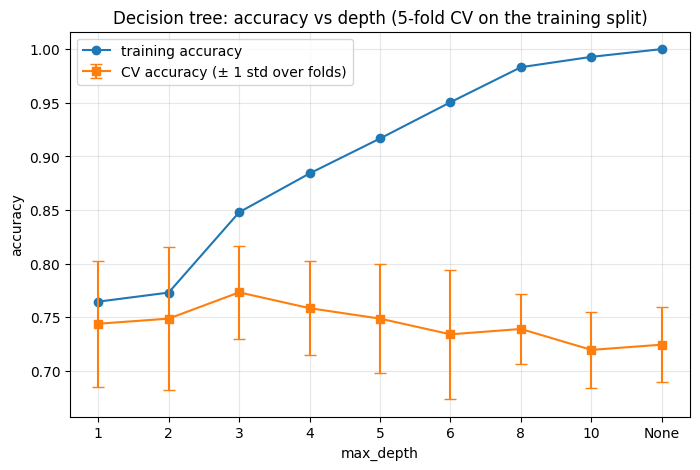

In [45]:
import matplotlib.pyplot as plt

x_pos = np.arange(len(depth_table))        # equal spacing: the last tick is "None"
labels = depth_table["max_depth"].astype(str)

plt.figure(figsize=(8, 5))
plt.plot(x_pos, depth_table["train_acc"], marker="o", label="training accuracy")
plt.errorbar(x_pos, depth_table["cv_acc"], yerr=depth_table["cv_std"],
             marker="s", capsize=4, label="CV accuracy (± 1 std over folds)")
plt.xticks(x_pos, labels)
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Decision tree: accuracy vs depth (5-fold CV on the training split)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Choosing the depth

**Selection rule (one-standard-error rule).** Let the best depth be the one with the highest mean CV accuracy, and let SE = std / √5 be the standard error of its mean over the 5 folds. Among all depths whose mean CV accuracy is at least (best mean − SE), choose the smallest one. The reason is that a shallower tree is simpler and less prone to over-fitting, and a difference smaller than one standard error cannot be told apart from fold-to-fold noise.

In [46]:
best_row = depth_table.loc[depth_table["cv_acc"].idxmax()]
se_best = best_row["cv_std"] / np.sqrt(5)
threshold = best_row["cv_acc"] - se_best

candidates = depth_table[depth_table["cv_acc"] >= threshold]
chosen_row = candidates.iloc[0]          # the table is sorted from the shallowest depth up
chosen_depth = chosen_row["max_depth"]

print("best depth:", best_row["max_depth"], "| cv_acc =", round(best_row["cv_acc"], 4),
      "| SE =", round(se_best, 4), "| threshold =", round(threshold, 4))
print("depths that pass the threshold:", list(candidates["max_depth"]))
print("chosen depth:", chosen_depth)
print(depth_table.assign(diff_from_best=(depth_table["cv_acc"] - best_row["cv_acc"]).round(4))[["max_depth", "cv_acc", "diff_from_best"]].to_string(index=False))

best depth: 3 | cv_acc = 0.7732 | SE = 0.0195 | threshold = 0.7537
depths that pass the threshold: [3, 4]
chosen depth: 3
max_depth   cv_acc  diff_from_best
        1 0.743902         -0.0293
        2 0.748664         -0.0245
        3 0.773171          0.0000
        4 0.758420         -0.0148
        5 0.748664         -0.0245
        6 0.734030         -0.0391
        8 0.739024         -0.0341
       10 0.719512         -0.0537
     None 0.724390         -0.0488


**Result.** The best mean CV accuracy is 0.7732 at depth 3, with SE = 0.0195, so the threshold is 0.7537. Depths 3 and 4 pass it, and the smallest one is **max_depth = 3**.

**Justification.** Depth 3 has the highest CV accuracy and is the simplest tree within one standard error of the best, while deeper trees fit the training set better (training accuracy 0.85 at depth 3, 1.0 at depth None) without any gain on the held-out folds.

**Is depth 3 clearly better than its neighbours?** No. It is 0.0148 above depth 4 (less than one SE) and 0.0245 above depth 2 (about 1.3 SE), while the std over folds is 0.04 to 0.07. These differences are small compared with the fold-to-fold noise, so depth 3 is a reasonable choice, but not a clear winner. What the data show clearly is only that very deep trees (depth 6 and more) are worse than depth 3 by 0.03 to 0.05.

In [47]:
leaf_grid = [1, 2, 5, 10, 20, 40]
rows = []
for m in leaf_grid:
    model = DecisionTreeClassifier(criterion="entropy", max_depth=None,
                                   min_samples_leaf=m, random_state=SEED)
    s = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy",
                       return_train_score=True, return_estimator=True)
    rows.append({
        "min_samples_leaf": m,
        "leaves": np.mean([est.get_n_leaves() for est in s["estimator"]]),
        "train_acc": s["train_score"].mean(),
        "cv_acc": s["test_score"].mean(),
        "cv_std": s["test_score"].std(),
    })
leaf_table = pd.DataFrame(rows)
print(leaf_table.round(4).to_string(index=False))

 min_samples_leaf  leaves  train_acc  cv_acc  cv_std
                1    28.8     1.0000  0.7244  0.0348
                2    26.2     0.9602  0.7050  0.0311
                5    17.2     0.8913  0.7633  0.0387
               10    10.6     0.8599  0.7825  0.0349
               20     6.0     0.7874  0.7197  0.0549
               40     3.4     0.7645  0.7439  0.0589


### A second brake: min_samples_leaf

Both brakes remove over-fitting: with a limit the training accuracy drops from 1.0 and the CV accuracy rises, to 0.7732 for max_depth = 3 and to 0.7825 for min_samples_leaf = 10, a difference of 0.0093 that is below one standard error and so cannot be told apart from noise. They differ in how they limit the tree: max_depth cuts all branches at the same level, while min_samples_leaf lets a branch with many patients grow deeper and stops a branch only when its leaves would become too small.

In [48]:
final_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED)
final_tree.fit(X_train, y_train)

test_acc = final_tree.score(X_test, y_test)
n_test = len(y_test)
se_test = np.sqrt(test_acc * (1 - test_acc) / n_test)

print("test accuracy:", round(test_acc, 4))
print("n =", n_test, "| standard error =", round(se_test, 4))
print("approx. range (± 1 SE):", round(test_acc - se_test, 4), "to", round(test_acc + se_test, 4))

test accuracy: 0.7667
n = 90 | standard error = 0.0446
approx. range (± 1 SE): 0.7221 to 0.8112


### Test, once

The chosen tree (max_depth = 3, trained on the full training split) has a test accuracy of **0.7667** (69 of 90 test patients). The standard error is sqrt(0.7667 · (1 − 0.7667) / 90) = **0.0446**, so the accuracy is about 0.77 ± 0.04. This agrees with the CV accuracy of the same depth (0.7732), which is within one standard error.

**What the gap at max_depth = None tells us.** The unlimited tree has a training accuracy of 1.0000 but a CV accuracy of only 0.7244, a gap of about 0.28: it has memorised the training patients, including their noise, and that memory does not carry over to patients it has not seen.